In [2]:

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load the dataset
df = pd.read_excel("../data/Telco_customer_churn.xlsx")
print(df.shape)


(7043, 33)


In [3]:
print(df.columns.tolist())
df.head()

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [16]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [5]:
print(df["Churn Label"].value_counts(normalize=True))                                  

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [7]:
print(df["Total Charges"].dtype)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print(df["Total Charges"].isna().sum())
mask = pd.to_numeric(df["Total Charges"],errors = "coerce").isna()
print(df.loc[mask, "Total Charges"].unique())



float64
11
[nan]


In [8]:
na_rows = df[df["Total Charges"].isna()]
print(na_rows[["Tenure Months","Monthly Charges","Churn Label"]])

      Tenure Months  Monthly Charges Churn Label
2234              0            52.55          No
2438              0            20.25          No
2568              0            80.85          No
2667              0            25.75          No
2856              0            56.05          No
4331              0            19.85          No
4687              0            25.35          No
5104              0            20.00          No
5719              0            19.70          No
6772              0            73.35          No
6840              0            61.90          No


In [9]:
df["Total Charges"]= df["Total Charges"].fillna(0)
print(df["Total Charges"].isna().sum())

0


In [10]:
print("Doublons:", df.duplicated().sum())
print(df["CustomerID"].duplicated().sum())
print(df.isna().sum()[df.isna().sum()>0])

Doublons: 0
0
Churn Reason    5174
dtype: int64


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     0.735
Yes    0.265
Name: proportion, dtype: float64


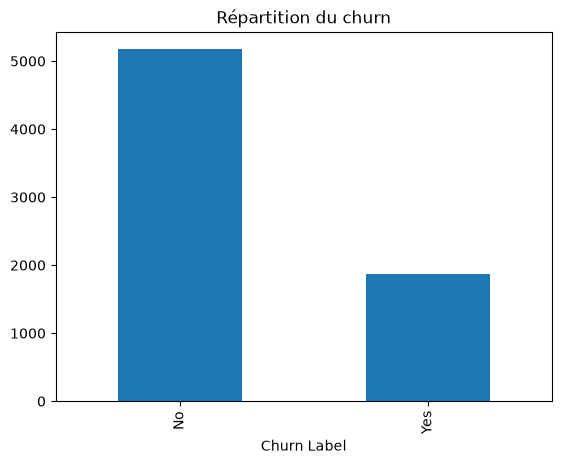

In [11]:
print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True).round(3))
df["Churn Label"].value_counts().plot(kind="bar", title="Répartition du churn")
plt.show()

Conclusion attendue : environ 26,5 % de churn, donc classes déséquilibrées. On utilisera le découpage stratifié, et on jugera le modèle sur le recall, la precision et la PR-AUC, pas sur l'accuracy.

            Tenure Months        Monthly Charges        Total Charges        
                     mean median            mean median          mean  median
Churn Label                                                                  
No                   37.6   38.0            61.3   64.4        2549.9  1679.5
Yes                  18.0   10.0            74.4   79.6        1531.8   703.6


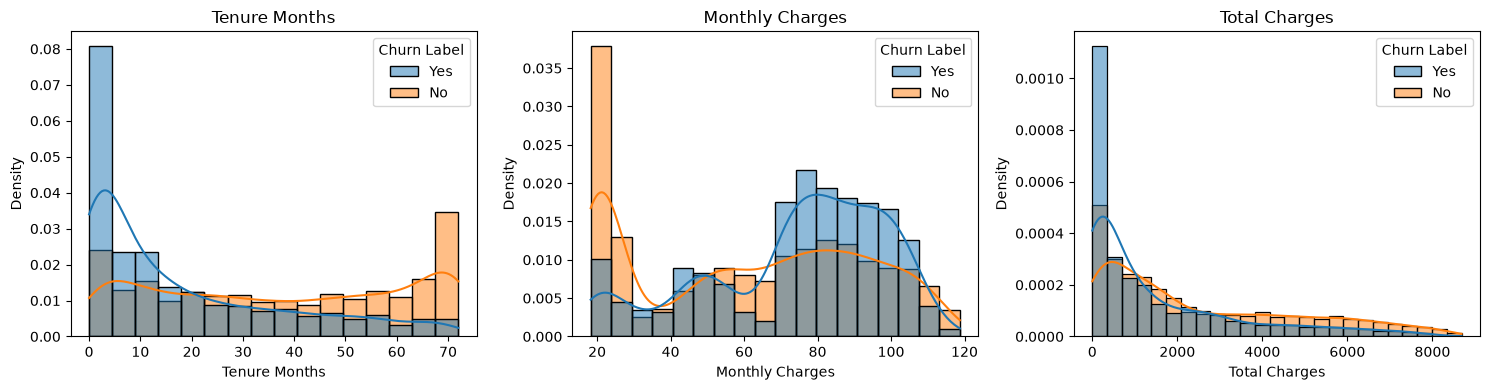

In [13]:
num_cols = ["Tenure Months","Monthly Charges", "Total Charges"]
print(df.groupby("Churn Label")[num_cols].agg(["mean","median"]).round(1))


fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax , c in zip(axes, num_cols):
    sns.histplot(data=df,x=c,hue="Churn Label", ax=ax, kde= True, stat = "density", common_norm=False )
    ax.set_title(c)
plt.tight_layout()
plt.show()
    

+ **Observation** : médiane d'ancienneté 10 mois chez les partis contre 38 chez les restés ; frais mensuels médians 79,6 contre 64,4.
+ **Conclusion** : le churn est concentré dans la première année et chez les clients à facture élevée. Total Charges reflète surtout l'ancienneté.
+ **Décision** : garder Tenure et Monthly Charges ; tester la redondance de Total Charges ; vérifier si l'effet du prix est expliqué par le type d'internet et le contrat.

In [15]:
cat_cols = ["Contract", "Payment Method", "Internet Service",
            "Senior Citizen", "Paperless Billing", "Tech Support", "Online Security"]
for c in cat_cols:
    t = df.groupby(c)["Churn Value"].agg(["mean","count"]).round(3)
    t.columns = ["taux_churn","effectif"]
    print(f"\n {c}\n{t.sort_values('taux_churn', ascending=False)}")


 Contract
                taux_churn  effectif
Contract                            
Month-to-month       0.427      3875
One year             0.113      1473
Two year             0.028      1695

 Payment Method
                           taux_churn  effectif
Payment Method                                 
Electronic check                0.453      2365
Mailed check                    0.191      1612
Bank transfer (automatic)       0.167      1544
Credit card (automatic)         0.152      1522

 Internet Service
                  taux_churn  effectif
Internet Service                      
Fiber optic            0.419      3096
DSL                    0.190      2421
No                     0.074      1526

 Senior Citizen
                taux_churn  effectif
Senior Citizen                      
Yes                  0.417      1142
No                   0.236      5901

 Paperless Billing
                   taux_churn  effectif
Paperless Billing                      
Yes                 

+ **Observation** : churn de 42,7 % en contrat mensuel contre 2,8 % en 2 ans ; 45,3 % en chèque électronique ; 41,9 % en fibre ; ~42 % sans support technique ni sécurité.
+ **Conclusion** : le contrat, le paiement, le type d'internet et les services additionnels sont fortement liés au churn, mais ces variables se chevauchent et aucune causalité n'est établie.
+ **Décision** : garder ces variables, croiser contrat × internet avant de conclure, surveiller la redondance des modalités "No internet service".

In [17]:
print(df.groupby("Internet Service")["Monthly Charges"].median())

Internet Service
DSL            56.150
Fiber optic    91.675
No             20.150
Name: Monthly Charges, dtype: float64


In [18]:
print(df.groupby(["Internet Service", "Churn Label"])["Monthly Charges"].median().unstack().round(1))

Churn Label         No   Yes
Internet Service            
DSL               59.8  49.2
Fiber optic       94.8  87.6
No                20.2  20.0


+ **Observation** : à type d'internet fixé, les partis ont des frais mensuels médians plus bas (DSL 49,2 vs 59,8 ; fibre 87,6 vs 94,8 ; sans internet 20,0 vs 20,2).
+ **Conclusion** : l'écart global de prix est un effet de composition (paradoxe de Simpson) : les partis sont plus souvent en fibre. Le prix seul n'explique pas le churn.
+ **Décision** : ne pas conclure que le prix fait partir les clients ; vérifier l'effet du type d'internet à contrat fixé.